# StyleGAN2 Latent Space Lab

This notebook demonstrates how to load a pretrained StyleGAN2 generator, sample latent vectors (z), generate images, and perform simple vector arithmetic in latent space to observe effects on generated images. The model file is expected at `download/ffhq.pkl`.

In [1]:
# Imports and helpers
import pickle as pkl
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import uuid

plt.rcParams['figure.figsize'] = [6,6]

# helper to convert synthesis output to PIL image
def synth_to_pil(img_tensor):
    # img_tensor: [B, C, H, W] float32 in range ~[-1,1]
    img = (img_tensor * 127.5 + 128).clamp(0, 255).to(torch.uint8).cpu().numpy()
    # take first image
    arr = img[0].transpose(1,2,0)
    return Image.fromarray(arr)

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

# Load StyleGAN2 generator and pretrained ffhq model

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


with open('download/ffhq.pkl', 'rb') as f:
    G = pkl.load(f)['G_ema'].to(device)
G.eval()
print('Loaded generator successfully. z_dim =', G.z_dim, 'img_resolution =', G.img_resolution)


Using device: mps
Loaded generator successfully. z_dim = 512 img_resolution = 1024


### 2 helper functions: 1) sample a z, and 2) generate image from z

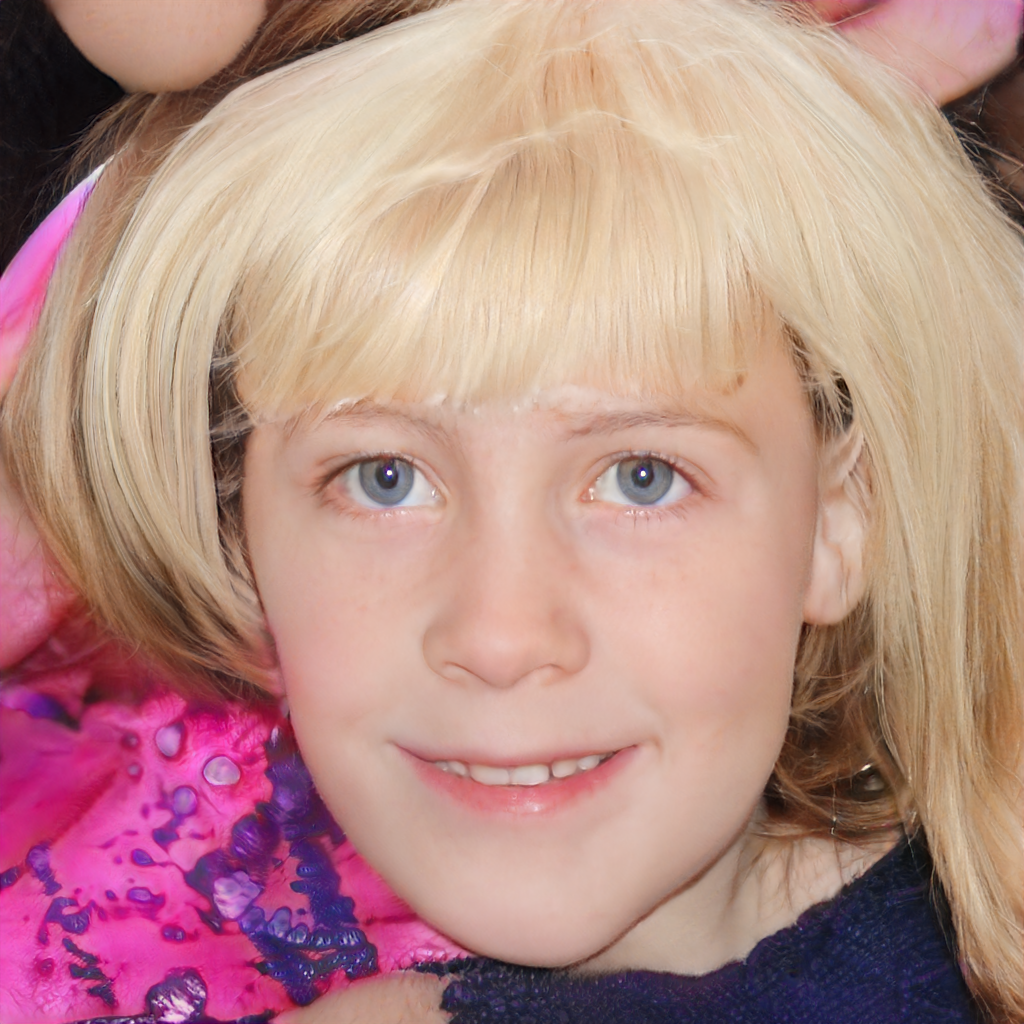

In [3]:
# Sample a random latent z and generate an image
def sample_z():
    return torch.randn([1, G.z_dim], device=device)

def z_to_image(z, save_path=None):
    with torch.no_grad():
        c = None
        w = G.mapping(z, c)
        # disable per-layer noise for reproducibility here
        img_tensor = G.synthesis(w)
        pil = synth_to_pil(img_tensor)
        if save_path is not None:
            ensure_dir(os.path.dirname(save_path))
            pil.save(save_path)
        return pil, w, img_tensor

# Example: generate one image, display at full sizes 
z = sample_z()
pil, w, img_tensor = z_to_image(z)
display(pil)


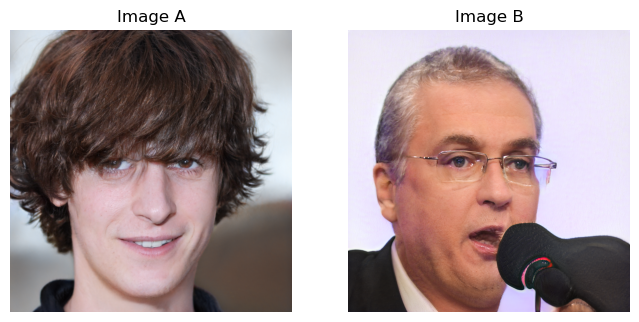

In [4]:
# Generate two images from two different latents and show side-by-side
z_a = torch.randn([1, G.z_dim], device=device)
z_b = torch.randn([1, G.z_dim], device=device)
pil_a, w_a, _ = z_to_image(z_a)
pil_b, w_b, _ = z_to_image(z_b)

fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].imshow(pil_a); axes[0].set_title('Image A'); axes[0].axis('off')
axes[1].imshow(pil_b); axes[1].set_title('Image B'); axes[1].axis('off')
plt.show()


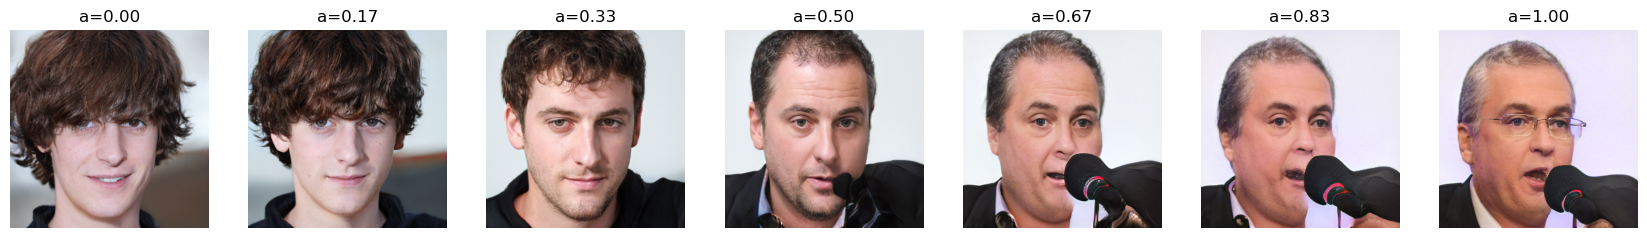

In [5]:
# Linear interpolation between z_a and z_b
def interpolate_z(z1, z2, steps=7):
    alphas = np.linspace(0,1,steps)
    imgs = []
    ws = []
    for a in alphas:
        z = (1 - a) * z1 + a * z2
        pil, w, _ = z_to_image(z)
        imgs.append(pil)
        ws.append(w)
    return alphas, imgs, ws

alphas, interp_imgs, interp_ws = interpolate_z(z_a, z_b, steps=7)
fig, axes = plt.subplots(1, len(interp_imgs), figsize=(3*len(interp_imgs),3))
for i, img in enumerate(interp_imgs):
    axes[i].imshow(img); axes[i].set_title(f'a={alphas[i]:.2f}'); axes[i].axis('off')
plt.show()

id_a = str(uuid.uuid4())
id_b = str(uuid.uuid4())

# Optionally save interpolation images
ensure_dir('./lab_data/interp')
for i,img in enumerate(interp_imgs):
    img.save(f'./lab_data/interp/{id_a}_{id_b}_{i}.png')


## Latent vector arithmetic

Below we perform simple arithmetic in the z space (the input noise). We compute A+B, A-B, and show results.

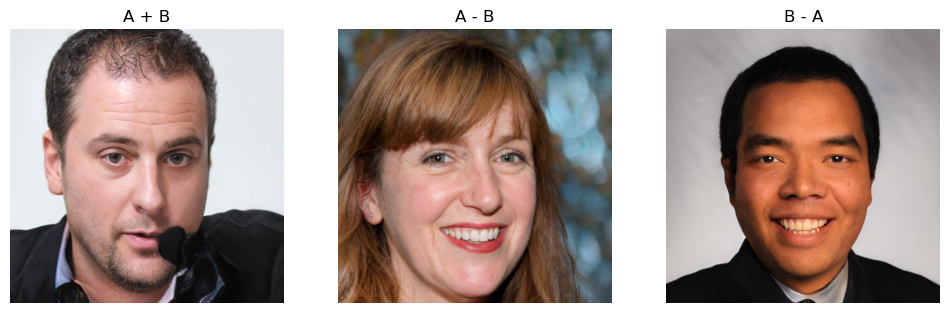

In [6]:
# addition
z_add = z_a + z_b
pil_add, _, _ = z_to_image(z_add)
# subtraction A - B
z_sub_ab = z_a - z_b
pil_sub_ab, _, _ = z_to_image(z_sub_ab)
# subtraction B - A
z_sub_ba = z_b - z_a
pil_sub_ba, _, _ = z_to_image(z_sub_ba)

fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(pil_add); axes[0].set_title('A + B'); axes[0].axis('off')
axes[1].imshow(pil_sub_ab); axes[1].set_title('A - B'); axes[1].axis('off')
axes[2].imshow(pil_sub_ba); axes[2].set_title('B - A'); axes[2].axis('off')
plt.show()


In [7]:
# Save latents and images for reuse
ensure_dir('./lab_data/latents')
ensure_dir('./lab_data/images')
id_a = str(uuid.uuid4())
id_b = str(uuid.uuid4())
torch.save(z_a.cpu(), f'./lab_data/latents/{id_a}.pth')
torch.save(z_b.cpu(), f'./lab_data/latents/{id_b}.pth')
pil_a.save(f'./lab_data/images/{id_a}.png')
pil_b.save(f'./lab_data/images/{id_b}.png')
print('Saved:', id_a, id_b)


Saved: 8ea84c55-58c4-4136-95e3-e90e970685d2 2bdaf201-89e7-4fe5-8fc5-6854fa1f213f
